## DTO Active-Set Analysis

This analysis identifies transcription factor (TF) binding samples that show
significant dual-threshold overlap (DTO) with both major perturbation datasets,
providing a high-confidence set of regulatory interactions.

### Workflow

1. **Filter by Hackett-2020-ZEV**: Select binding samples from all datasets
   (Harbison, Rossi, Mahendrawada) where DTO vs. Hackett-2020-ZEV P ≤ 0.01.

2. **Filter by Kemmeren-2014-TFKO**: Apply the same selection against the
   Kemmeren-2014 knockout perturbation dataset (P ≤ 0.01).

3. **Intersect**: Retain only binding samples that are significant in **both**
   comparisons. These form the "active set" — samples whose regulatory
   relationships are independently supported by two orthogonal perturbation
   experiments (ZEV-inducible overexpression and gene knockout).

4. **Summarize by regulator**:
   - **Table**: One row per regulator with the count of active samples.
   - **Distribution**: Histogram showing how many regulators have 1, 2, 3, …
     active samples, revealing whether active evidence is concentrated in a
     few TFs or spread broadly.

### Rationale

A binding sample significant in only one perturbation comparison could reflect
experiment-specific artifacts. Requiring significance in both Hackett (ZEV) and
Kemmeren (TFKO) leverages two fundamentally different perturbation strategies,
increasing confidence that the observed TF–target relationships are
biologically meaningful.

In [53]:
from tfbpapi.virtual_db import VirtualDB

# Read configuration from datasets.yaml
vdb = VirtualDB("/home/luegg/code/tfbpapi/tfbpapi/datasets.yaml")
print(repr(vdb))

VirtualDB(7 repos, 8 datasets, views not yet registered)


In [54]:
# List all registered views
print("Registered views:")
for name in vdb.tables():
    print(f"  {name}")

Registered views:


Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 146996.64it/s]
Key 'carbon_source' not found at path 'media.carbon_source' (current keys: ['name'])
Key 'carbon_source' not found at path 'media.carbon_source' (current keys: ['name'])
Key 'carbon_source' not found at path 'media.carbon_source' (current keys: ['name'])
Key 'temperature_celsius' not found at path 'temperature_celsius' (current keys: ['description', 'initial_temperature_celsius', 'temperature_shift_celsius', 'temperature_shift_duration_minutes', 'growth_phase_at_harvest', 'media'])


  chec_mahendrawada_m2025_af_combined_meta
  chec_mahendrawada_m2025_af_combined_meta_meta
  dto_expanded
  hackett
  hackett_meta
  harbison
  harbison_meta
  kemmeren
  kemmeren_meta
  knockout
  knockout_meta
  overexpression
  overexpression_meta
  rossi_2021_af_combined
  rossi_2021_af_combined_meta


## Step1-Obtain the intersection of the binding dataset and Hackett

In [55]:
# Using binding dataset as the main table, JOIN dto_expanded to retrieve DTO statistics
# Filtering for vs. Hackett perturbation data, pvalue <= 0.01
harbison_hackett = vdb.query("""
    SELECT
        h.sample_id,
        h.regulator_symbol,
        h.regulator_locus_tag,
        h.condition,
        h.carbon_source,
        h.temperature_celsius,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS hackett_sample_id,
        d.perturbation_id_source
    FROM harbison_meta h
    JOIN dto_expanded d
        ON CAST(h.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source = 'harbison'
    WHERE d.perturbation_id_source = 'hackett'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(harbison_hackett)}")
harbison_hackett.head(10)

Number of records that meet the criteria: 910


,sample_id,regulator_symbol,regulator_locus_tag,condition,carbon_source,temperature_celsius,dto_empirical_pvalue,dto_fdr,hackett_sample_id,perturbation_id_source
0,16,TEC1,YBR083W,Alpha,glucose,30.0,0.0,0.141768,91,hackett
1,174,ZAP1,YJL056C,YPD,glucose,30.0,0.0,0.005249,818,hackett
2,38,PHO2,YDL106C,H2O2Hi,glucose,30.0,0.0,0.263801,190,hackett
3,248,SOK2,YMR016C,BUT14,glucose,30.0,0.0,0.065595,1098,hackett
4,50,NRG1,YDR043C,H2O2Lo,glucose,30.0,0.0,0.167487,249,hackett
5,50,NRG1,YDR043C,H2O2Lo,glucose,30.0,0.0,0.241330,248,hackett
6,323,DIG1,YPL049C,BUT90,glucose,30.0,0.0,0.031633,1598,hackett
7,281,GCR2,YNL199C,SM,unspecified,30.0,0.0,0.001701,1251,hackett
8,86,GLN3,YER040W,SM,unspecified,30.0,0.0,0.099947,434,hackett
9,282,GCR2,YNL199C,YPD,glucose,30.0,0.0,0.047443,1251,hackett


In [56]:
rossi_hackett = vdb.query("""
    SELECT
        r.sample_id,
        r.regulator_locus_tag,
        r.carbon_source,
        r.temperature_celsius,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS hackett_sample_id,
        d.perturbation_id_source
    FROM (
        SELECT DISTINCT
            sample_id,
            regulator_locus_tag,
            carbon_source,
            temperature_celsius
        FROM rossi_2021_af_combined_meta
    ) r
    JOIN dto_expanded d
        ON CAST(r.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source = 'rossi_2021_af_combined'
    WHERE d.perturbation_id_source = 'hackett'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(rossi_hackett)}")
rossi_hackett.head(10)

Number of records that meet the criteria: 684


,sample_id,regulator_locus_tag,carbon_source,temperature_celsius,dto_empirical_pvalue,dto_fdr,hackett_sample_id,perturbation_id_source
0,671,YOR083W,glucose,25,0.0,0.002385,1393,hackett
1,550,YMR039C,glucose,25,0.0,0.023965,1132,hackett
2,154,YDR216W,glucose,25,0.0,0.082601,304,hackett
3,392,YJL110C,glucose,25,0.0,0.124665,799,hackett
4,700,YOR290C,glucose,25,0.0,0.079160,1454,hackett
5,372,YIL131C,glucose,25,0.0,0.059436,732,hackett
6,700,YOR290C,glucose,25,0.0,0.070062,1453,hackett
7,372,YIL131C,glucose,25,0.0,0.076569,731,hackett
8,700,YOR290C,glucose,25,0.0,0.093879,1452,hackett
9,372,YIL131C,glucose,25,0.0,0.108097,730,hackett


In [57]:
mahendrawada_hackett = vdb.query("""
    SELECT
        m.sample_id,
        m.regulator_locus_tag,
        m.regulator_symbol,
        m.condition,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS hackett_sample_id,
        d.perturbation_id_source
    FROM (
        SELECT DISTINCT
            sample_id,
            regulator_locus_tag,
            regulator_symbol,
            condition
        FROM chec_mahendrawada_m2025_af_combined_meta
    ) m
    JOIN dto_expanded d
        ON CAST(m.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source LIKE '%mahendrawada%af_combined%'
    WHERE d.perturbation_id_source = 'hackett'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(mahendrawada_hackett)}")
mahendrawada_hackett.head(10)

Number of records that meet the criteria: 946


,sample_id,regulator_locus_tag,regulator_symbol,condition,dto_empirical_pvalue,dto_fdr,hackett_sample_id,perturbation_id_source
0,1,YBL005W,PDR3,standard,0.0,0.004227,82,hackett
1,1,YBL005W,PDR3,standard,0.0,0.025297,83,hackett
2,1,YBL005W,PDR3,standard,0.0,0.040956,84,hackett
3,1,YBL005W,PDR3,standard,0.0,0.031786,85,hackett
4,1,YBL005W,PDR3,standard,0.0,0.018509,86,hackett
5,1,YBL005W,PDR3,standard,0.0,0.017014,87,hackett
6,1,YBL005W,PDR3,standard,0.0,0.016319,88,hackett
7,100,YJL056C,ZAP1,standard,0.0,0.000000,817,hackett
8,100,YJL056C,ZAP1,standard,0.0,0.000915,818,hackett
9,100,YJL056C,ZAP1,standard,0.0,0.000760,819,hackett


In [58]:
import pandas as pd

common_cols = [
    "sample_id", "regulator_locus_tag",
    "dto_empirical_pvalue", "dto_fdr",
    "hackett_sample_id", "perturbation_id_source"
]

harbison_hackett["source_dataset"] = "harbison"
rossi_hackett["source_dataset"] = "rossi"
mahendrawada_hackett["source_dataset"] = "mahendrawada"

hackett_all = pd.concat([
    harbison_hackett[common_cols + ["source_dataset"]],
    rossi_hackett[common_cols + ["source_dataset"]],
    mahendrawada_hackett[common_cols + ["source_dataset"]],
], ignore_index=True)

print(f"Total number of records after merging: {len(hackett_all)}")
print(f"\nDistribution of each dataset:")
print(hackett_all["source_dataset"].value_counts())
hackett_all.head(10)

Total number of records after merging: 2540

Distribution of each dataset:
source_dataset
mahendrawada    946
harbison        910
rossi           684
Name: count, dtype: int64


,sample_id,regulator_locus_tag,dto_empirical_pvalue,dto_fdr,hackett_sample_id,perturbation_id_source,source_dataset
0,16,YBR083W,0.0,0.141768,91,hackett,harbison
1,174,YJL056C,0.0,0.005249,818,hackett,harbison
2,38,YDL106C,0.0,0.263801,190,hackett,harbison
3,248,YMR016C,0.0,0.065595,1098,hackett,harbison
4,50,YDR043C,0.0,0.167487,249,hackett,harbison
5,50,YDR043C,0.0,0.241330,248,hackett,harbison
6,323,YPL049C,0.0,0.031633,1598,hackett,harbison
7,281,YNL199C,0.0,0.001701,1251,hackett,harbison
8,86,YER040W,0.0,0.099947,434,hackett,harbison
9,282,YNL199C,0.0,0.047443,1251,hackett,harbison


## Step2-Obtain the intersection of the binding dataset and kemmern

In [59]:
harbison_kemmeren = vdb.query("""
    SELECT
        h.sample_id,
        h.regulator_symbol,
        h.regulator_locus_tag,
        h.condition,
        h.carbon_source,
        h.temperature_celsius,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS kemmeren_sample_id,
        d.perturbation_id_source
    FROM harbison_meta h
    JOIN dto_expanded d
        ON CAST(h.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source = 'harbison'
    WHERE d.perturbation_id_source = 'kemmeren'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(harbison_kemmeren)}")
harbison_kemmeren.head(10)

Number of records that meet the criteria: 224


,sample_id,regulator_symbol,regulator_locus_tag,condition,carbon_source,temperature_celsius,dto_empirical_pvalue,dto_fdr,kemmeren_sample_id,perturbation_id_source
0,70,SUM1,YDR310C,YPD,glucose,30.0,0.0,0.013631,299,kemmeren
1,151,STE12,YHR084W,Alpha,glucose,30.0,0.0,0.128768,622,kemmeren
2,319,MET31,YPL038W,SM,unspecified,30.0,0.0,0.021299,1367,kemmeren
3,70,SUM1,YDR310C,YPD,glucose,30.0,0.0,0.006238,299,kemmeren
4,151,STE12,YHR084W,Alpha,glucose,30.0,0.0,0.117883,622,kemmeren
5,242,GAL80,YML051W,YPD,glucose,30.0,0.0,0.000000,1006,kemmeren
6,319,MET31,YPL038W,SM,unspecified,30.0,0.0,0.026317,1367,kemmeren
7,323,DIG1,YPL049C,BUT90,glucose,30.0,0.0,0.236502,1372,kemmeren
8,49,NRG1,YDR043C,H2O2Hi,glucose,30.0,0.0,0.230039,221,kemmeren
9,198,RGT1,YKL038W,YPD,glucose,30.0,0.0,0.003463,786,kemmeren


In [60]:
rossi_kemmeren = vdb.query("""
    SELECT
        r.sample_id,
        r.regulator_locus_tag,
        r.carbon_source,
        r.temperature_celsius,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS kemmeren_sample_id,
        d.perturbation_id_source
    FROM (
        SELECT DISTINCT
            sample_id,
            regulator_locus_tag,
            carbon_source,
            temperature_celsius
        FROM rossi_2021_af_combined_meta
    ) r
    JOIN dto_expanded d
        ON CAST(r.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source = 'rossi_2021_af_combined'
    WHERE d.perturbation_id_source = 'kemmeren'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(rossi_kemmeren)}")
rossi_kemmeren.head(10)

Number of records that meet the criteria: 389


,sample_id,regulator_locus_tag,carbon_source,temperature_celsius,dto_empirical_pvalue,dto_fdr,kemmeren_sample_id,perturbation_id_source
0,478,YLR182W,glucose,25,0.0,0.084524,913,kemmeren
1,291,YGL237C,glucose,25,0.0,0.010760,521,kemmeren
2,208,YEL018W,glucose,25,0.0,0.218327,361,kemmeren
3,487,YLR256W,glucose,25,0.0,0.000000,932,kemmeren
4,269,YGL071W,glucose,25,0.0,0.174709,471,kemmeren
5,32,YBR010W,glucose,25,0.0,0.240309,60,kemmeren
6,470,YLR098C,glucose,25,0.0,0.000020,894,kemmeren
7,467,YLR085C,glucose,25,0.0,0.252903,889,kemmeren
8,639,YOL004W,glucose,25,0.0,0.215319,1233,kemmeren
9,21,YBL021C,glucose,25,0.0,0.056864,39,kemmeren


In [61]:
mahendrawada_kemmeren = vdb.query("""
    SELECT
        m.sample_id,
        m.regulator_locus_tag,
        m.regulator_symbol,
        m.condition,
        d.dto_empirical_pvalue,
        d.dto_fdr,
        d.perturbation_id_id   AS kemmeren_sample_id,
        d.perturbation_id_source
    FROM (
        SELECT DISTINCT
            sample_id,
            regulator_locus_tag,
            regulator_symbol,
            condition
        FROM chec_mahendrawada_m2025_af_combined_meta
    ) m
    JOIN dto_expanded d
        ON CAST(m.sample_id AS VARCHAR) = d.binding_id_id
        AND d.binding_id_source LIKE '%mahendrawada%af_combined%'
    WHERE d.perturbation_id_source = 'kemmeren'
      AND d.dto_empirical_pvalue <= 0.01
    ORDER BY d.dto_empirical_pvalue
""")

print(f"Number of records that meet the criteria: {len(mahendrawada_kemmeren)}")
mahendrawada_kemmeren.head(10)

Number of records that meet the criteria: 262


,sample_id,regulator_locus_tag,regulator_symbol,condition,dto_empirical_pvalue,dto_fdr,kemmeren_sample_id,perturbation_id_source
0,1,YBL005W,PDR3,standard,0.0,0.077667,31,kemmeren
1,5,YBR083W,TEC1,standard,0.0,0.065859,74,kemmeren
2,100,YJL056C,ZAP1,standard,0.0,0.302421,709,kemmeren
3,101,YJL110C,GZF3,standard,0.0,0.117351,723,kemmeren
4,102,YJL176C,SWI3,standard,0.0,0.127255,736,kemmeren
5,9,YBR239C,ERT1,standard,0.0,0.147725,106,kemmeren
6,104,YJR060W,CBF1,standard,0.0,0.166077,754,kemmeren
7,106,YJR140C,HIR3,standard,0.0,0.358890,772,kemmeren
8,90,YHR178W,STB5,standard,0.0,0.315486,642,kemmeren
9,11,YBR289W,SNF5,standard,0.0,0.133379,120,kemmeren


In [62]:
import pandas as pd

common_cols = [
    "sample_id", "regulator_locus_tag",
    "dto_empirical_pvalue", "dto_fdr",
    "kemmeren_sample_id", "perturbation_id_source"
]

harbison_kemmeren["source_dataset"] = "harbison"
rossi_kemmeren["source_dataset"] = "rossi"
mahendrawada_kemmeren["source_dataset"] = "mahendrawada"

kemmeren_all = pd.concat([
    harbison_kemmeren[common_cols + ["source_dataset"]],
    rossi_kemmeren[common_cols + ["source_dataset"]],
    mahendrawada_kemmeren[common_cols + ["source_dataset"]],
], ignore_index=True)

print(f"Total number of records after merging: {len(kemmeren_all)}")
print(f"\nDistribution among datasets:")
print(kemmeren_all["source_dataset"].value_counts())
kemmeren_all.head(10)

Total number of records after merging: 875

Distribution among datasets:
source_dataset
rossi           389
mahendrawada    262
harbison        224
Name: count, dtype: int64


,sample_id,regulator_locus_tag,dto_empirical_pvalue,dto_fdr,kemmeren_sample_id,perturbation_id_source,source_dataset
0,70,YDR310C,0.0,0.013631,299,kemmeren,harbison
1,151,YHR084W,0.0,0.128768,622,kemmeren,harbison
2,319,YPL038W,0.0,0.021299,1367,kemmeren,harbison
3,70,YDR310C,0.0,0.006238,299,kemmeren,harbison
4,151,YHR084W,0.0,0.117883,622,kemmeren,harbison
5,242,YML051W,0.0,0.000000,1006,kemmeren,harbison
6,319,YPL038W,0.0,0.026317,1367,kemmeren,harbison
7,323,YPL049C,0.0,0.236502,1372,kemmeren,harbison
8,49,YDR043C,0.0,0.230039,221,kemmeren,harbison
9,198,YKL038W,0.0,0.003463,786,kemmeren,harbison


## Step3-Take the intersection of Hackett and Kemmern

In [63]:
# Use (source_dataset, sample_id) to uniquely identify a binding sample
hackett_keys = hackett_all[["source_dataset", "sample_id", "regulator_locus_tag"]].drop_duplicates()
kemmeren_keys = kemmeren_all[["source_dataset", "sample_id", "regulator_locus_tag"]].drop_duplicates()

# Inner join = intersection
active_set = pd.merge(
    hackett_keys,
    kemmeren_keys,
    on=["source_dataset", "sample_id", "regulator_locus_tag"],
    how="inner"
)

print(f"Number of significant samples in Hackett: {len(hackett_keys)}")
print(f"Number of significant samples in Kemmeren: {len(kemmeren_keys)}")
print(f"Intersection (active set): {len(active_set)}")
print(f"\nDistribution among datasets:")
print(active_set["source_dataset"].value_counts())
active_set.head(10)

Number of significant samples in Hackett: 404
Number of significant samples in Kemmeren: 472
Intersection (active set): 278

Distribution among datasets:
source_dataset
mahendrawada    104
harbison         96
rossi            78
Name: count, dtype: int64


,source_dataset,sample_id,regulator_locus_tag
0,harbison,16,YBR083W
1,harbison,248,YMR016C
2,harbison,50,YDR043C
3,harbison,323,YPL049C
4,harbison,281,YNL199C
5,harbison,86,YER040W
6,harbison,282,YNL199C
7,harbison,18,YBR083W
8,harbison,7,YBL103C
9,harbison,225,YLR176C


## Step4-Statistics

In [64]:
regulator_counts = (
    active_set
    .groupby("regulator_locus_tag")
    .agg(
        n_active_samples=("sample_id", "nunique"),
        datasets=("source_dataset", lambda x: ", ".join(sorted(x.unique())))
    )
    .sort_values("n_active_samples", ascending=False)
    .reset_index()
)

print(f"There are {len(regulator_counts)} different regulators in the active set.")
regulator_counts.head(20)

There are 119 different regulators in the active set.


,regulator_locus_tag,n_active_samples,datasets
0,YEL009C,18,"harbison, mahendrawada, rossi"
1,YHR206W,6,"harbison, mahendrawada, rossi"
2,YBL103C,6,"harbison, mahendrawada, rossi"
3,YPL049C,6,"harbison, mahendrawada, rossi"
4,YDR043C,5,"harbison, mahendrawada, rossi"
5,YDL056W,5,"harbison, mahendrawada, rossi"
6,YHR084W,5,"harbison, mahendrawada, rossi"
7,YMR037C,5,"harbison, mahendrawada"
8,YNL068C,5,"harbison, mahendrawada, rossi"
9,YER040W,4,"harbison, mahendrawada, rossi"


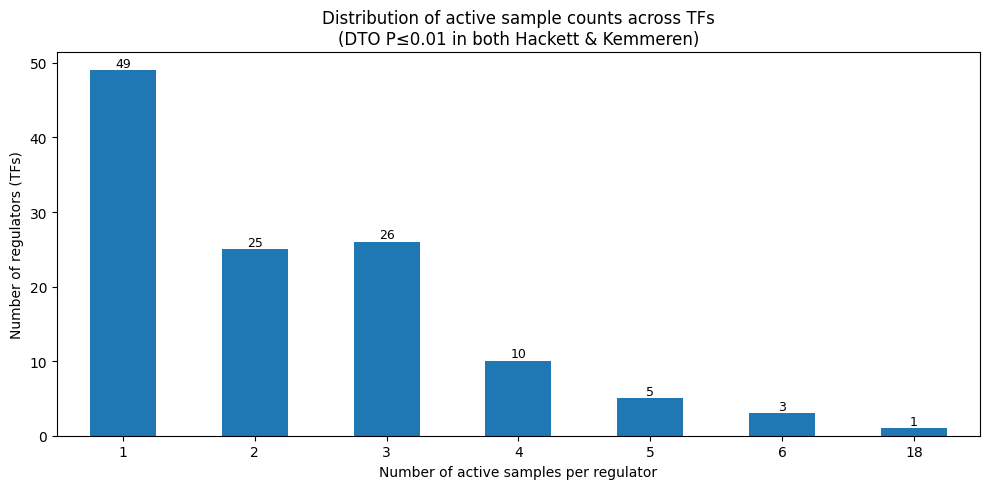

In [65]:
import matplotlib.pyplot as plt

dist = regulator_counts["n_active_samples"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
dist.plot(kind="bar", ax=ax)
ax.set_xlabel("Number of active samples per regulator")
ax.set_ylabel("Number of regulators (TFs)")
ax.set_title("Distribution of active sample counts across TFs\n(DTO P≤0.01 in both Hackett & Kemmeren)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (x, y) in enumerate(zip(dist.index, dist.values)):
    ax.text(i, y + 0.5, str(y), ha="center", fontsize=9)

plt.tight_layout()
plt.show()